In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Load an image
file_im = '../../ProjectInDataScience2026_Exercises/02_Images/example_im.png'
file_mask = '../../data/masks/PAT_15_3138_959_mask.png'

im = plt.imread(file_im)
mask = plt.imread(file_mask)
mask = mask > 0

We can display the image and mask real quick to see what we are working with.

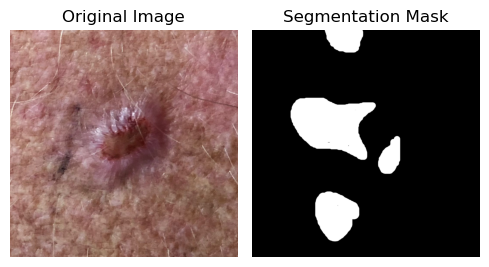

In [40]:
def display_images(im1, im2, title_1: str, title_2: str):
    # Display im and mask side by side
    fig, axes = plt.subplots(1, 2, figsize=(5, 3))
    # Display im1
    axes[0].imshow(im1, cmap='gray')
    axes[0].set_title(title_1)
    axes[0].axis('off')
    # Display im2
    axes[1].imshow(im2, cmap='gray')
    axes[1].set_title(title_2)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    return

display_images(im, mask, 'Original Image', 'Segmentation Mask')

# Assymetry metric

Prefectly spherical assymetry metric

In [ ]:
from skimage.measure import label, regionprops

#Contains information about shape of mask eg. center, area
props1 = regionprops(mask.astype(int))[0]

#Find the center of the mask
cy1, cx1 = props1.centroid

#All angles in radians
angles1 = np.deg2rad(np.arange(360))

def radial_distance(mask, cx, cy, theta, max_radius=1000):
    """Measures how far the shape extendes in one direction.
    Theta is the angle(direction), max_radius is just a safety limit so we don't loop forever"""
    
    #Starts walking outward from the center
    for r in range(1, max_radius):
        x1 = int(cx1 + r *np.cos(theta))
        y1 = int(cy1 + r * np.sin(theta))

        #checks if we walked outside the image
        if x1 < 0 or x1 >= mask.shape[1] or y1 < 0 or y1 >= mask.shape[0]:
            return r
    
        #checks if we left the mask
        if mask[y1, x1] == 0:
            return r
    
    #in case we never hit the edge
    return max_radius


#measure all 360 directions
radii1 = [radial_distance(mask, cx1, cy1, th) for th in angles1]

#turn list into numpy array
radii1 = np.array(radii1)

#compute assymetry score by standard deviation divided by mean
assymetry_score1 = np.std(radii1) / np.mean(radii1)






#test on the example mask
print("Assymetry score:", assymetry_score1)


Assymetry score: 0.11202050541459681


# Asymmetry score using 2020 Mabrouk research paper method


It gives a lesion a value of either 0, 1, or 2 where 0 is symmetrical and 2 is very assymetrical

In [42]:
import numpy as np
from skimage.measure import label, regionprops
from skimage.segmentation import find_boundaries
from skimage.transform import rotate

def Mabrouk_find_axis(mask):
    """Finds the axis at which the boundary is closest to the centroid,
    as done in the 2020 Mabrouk method of finding asymmetry score"""

    #Find the centroid of our mask
    props = regionprops(mask.astype(int))[0]
    Yc, Xc = props.centroid

    #Extract boundary pixels
    boundary = find_boundaries(mask, mode='outer')
    ys, xs = np.where(boundary)

    #vector from centroid to each boundary
    dy = ys - Yc
    dx = xs - Xc

    #angles and distance of each boundary pixel
    angles = np.arctan2(dy, dx)
    angles_deg = (np.degrees(angles) +360) % 360

    distance = np.sqrt(dx*dx + dy*dy)

    #binning by angle and keeping the closest boundary
    bins = np.arange(360)
    min_dist = np.full(360, np.inf)

    for a, d in zip(angles_deg.astype(int), distance):
        if d < min_dist[a]:
            min_dist[a] = d
    
    #Extracting the axis with the closest boundary
    closest_axes = np.where(min_dist == np.min(min_dist))[0]

    return closest_axes

def reflect_mask(mask, angle_deg):
    """Reflects the mask across an axis passing through the centroid at angle_deg"""

    #Rotate so axis becomes vertical
    rot = rotate(mask, -angle_deg, order=0, preserve_range=True)
    rot = rot >0.5

    #reflect horizontally
    refl = np.fliplr(rot)

    #rotate back
    refl_back = rotate(refl, angle_deg, order=0, preserve_range=True)
    refl_back = refl_back > 0.5

    return refl_back

def delta_A(mask, reflected):
    """Computes the non-overlapping area"""

    xor = np.logical_xor(mask, reflected)
    return xor.sum()

def Mabrouk_asymmetry(mask):
    """Computes the asymmetry score using the method from the 2020 Mabrouk research paper on skin lesion diagnosis"""

    #Find axis closest to centroid
    axis1 = int(Mabrouk_find_axis(mask)[0])
    axis2 = (axis1 + 90) % 360

    #Reflect across both axes
    refl1 = reflect_mask(mask, axis1)
    refl2 = reflect_mask(mask, axis2)

    #compute delta A for each axis
    A = mask.sum()
    dA1 = delta_A(mask, refl1)
    dA2 = delta_A(mask, refl2)

    #Compute asymmetry index for each axis
    AI1 = dA1 / A
    AI2 = dA2 / A

    #Final asymmetry score (0, 1, or 2)
    score = int(AI1 > 1) + int(AI2 > 1)

    return score, (AI1, AI2), (axis1,axis2)







